<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/RFSF_O3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
df = pd.read_csv("yearly_O3_2015.csv")
df.head()

,Station,Average,Type,Area,Longitude,Latitude,Altitude
0,ES1834A,56.246,Traffic,Urban,-0.0261,39.9889,18.0
1,ES1428A,45.210,Industrial,Suburban,-0.0361,39.9592,44.0
2,FR12042,53.647,Background,Urban,-0.0405,43.0962,403.0
3,ES0813A,83.561,Industrial,Rural,-0.0575,40.8419,830.0
4,ES1690A,57.710,Background,Rural,-0.0789,40.2694,259.0


In [9]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# --- Load Data ---
nc_file_path = "EMEP_yearly_2015.nc"
csv_file_path = "yearly_O3_2015.csv"

# --- Load NetCDF Data ---
nc_data = xr.open_dataset(nc_file_path)

lon_values = nc_data["lon"].values
lat_values = nc_data["lat"].values
o3_grid = nc_data["SURF_ug_O3"].values.squeeze()

# --- Create grid points (lat, lon) ---
lon_grid, lat_grid = np.meshgrid(lon_values, lat_values)

grid_points_deg = np.column_stack((
    lat_grid.ravel(),
    lon_grid.ravel()
))
grid_points_rad = np.radians(grid_points_deg)

o3_values = o3_grid.ravel()

# --- Load Station Data ---
station_data = pd.read_csv(csv_file_path)

station_lons = station_data["Longitude"].values
station_lats = station_data["Latitude"].values

station_coords_deg = np.column_stack((
    station_lats,
    station_lons
))
station_coords_rad = np.radians(station_coords_deg)

# --- Nearest Grid Cell Matching (Haversine) ---
tree = BallTree(grid_points_rad, metric="haversine")
distances_rad, indices = tree.query(station_coords_rad, k=1)

nearest_indices = indices.flatten()
nearest_grid_coords = grid_points_deg[nearest_indices]   # (lat, lon)
nearest_o3_values = o3_values[nearest_indices]

# --- Create Output DataFrame (KEEP ALL ORIGINAL FEATURES) ---
df_matched = station_data.copy()

df_matched["nearest_grid_lon"] = nearest_grid_coords[:, 1]
df_matched["nearest_grid_lat"] = nearest_grid_coords[:, 0]
df_matched["grid_cell_index"] = list(
    zip(nearest_grid_coords[:, 1], nearest_grid_coords[:, 0])
)
df_matched["nearest_SURF_ug_O3"] = nearest_o3_values

# --- Save to CSV ---
df_matched.to_csv("baseO3nearest_grid.csv", index=False)

print("Done. File saved as 'baseO3nearest_grid.csv'")


Done. File saved as 'baseO3nearest_grid.csv'


In [11]:
import numpy as np
import pandas as pd
dfnew = pd.read_csv("baseO3nearest_grid.csv")
dfnew.head()

,Station,Average,Type,Area,Longitude,Latitude,Altitude,nearest_grid_lon,nearest_grid_lat,grid_cell_index,nearest_SURF_ug_O3
0,ES1834A,56.246,Traffic,Urban,-0.0261,39.9889,18.0,-0.05,39.95,"(np.float64(-0.049999999999574385), np.float64...",57.27645
1,ES1428A,45.210,Industrial,Suburban,-0.0361,39.9592,44.0,-0.05,39.95,"(np.float64(-0.049999999999574385), np.float64...",57.27645
2,FR12042,53.647,Background,Urban,-0.0405,43.0962,403.0,-0.05,43.05,"(np.float64(-0.049999999999574385), np.float64...",69.95984
3,ES0813A,83.561,Industrial,Rural,-0.0575,40.8419,830.0,-0.05,40.85,"(np.float64(-0.049999999999574385), np.float64...",73.99349
4,ES1690A,57.710,Background,Rural,-0.0789,40.2694,259.0,-0.05,40.25,"(np.float64(-0.049999999999574385), np.float64...",72.04140


In [15]:
import pandas as pd

# Load original file
df = pd.read_csv("baseO3nearest_grid.csv")

# Remove points near 20°S (Southern Hemisphere)
df_clean = df[df["Latitude"] > 0].copy()

# Save cleaned file
df_clean.to_csv("baseO3nearest_grid.csv", index=False)

print("File overwritten.")
print("Original points:", len(df))
print("Remaining points:", len(df_clean))


File overwritten.
Original points: 1754
Remaining points: 1747


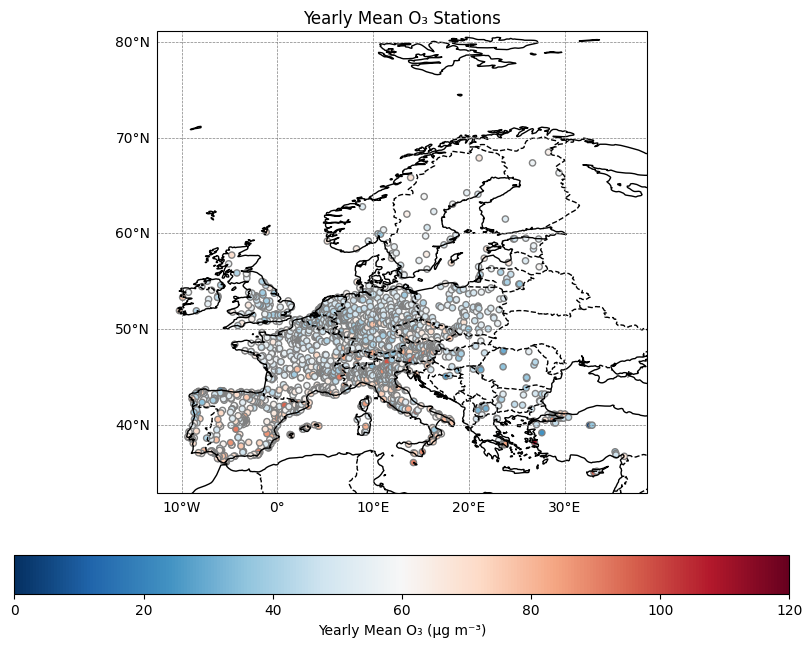

In [19]:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Load cleaned station data
stations = pd.read_csv("baseO3nearest_grid.csv")

# Fixed colour scale (same philosophy as residuals)
cbar_min = 0
cbar_max = 120

# Create map
fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Scatter plot (same style)
sc = ax.scatter(
    stations["Longitude"],
    stations["Latitude"],
    c=stations["Average"],
    cmap="RdBu_r",
    vmin=cbar_min,
    vmax=cbar_max,
    edgecolors="grey",
    s=20,
    transform=ccrs.PlateCarree()
)

# Horizontal colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.1)
cbar.set_label("Yearly Mean O₃ (μg m⁻³)")

# Title
ax.set_title("Yearly Mean O₃ Stations")

plt.show()

In [20]:
stations.head()

,Station,Average,Type,Area,Longitude,Latitude,Altitude,nearest_grid_lon,nearest_grid_lat,grid_cell_index,nearest_SURF_ug_O3
0,ES1834A,56.246,Traffic,Urban,-0.0261,39.9889,18.0,-0.05,39.95,"(np.float64(-0.049999999999574385), np.float64...",57.27645
1,ES1428A,45.210,Industrial,Suburban,-0.0361,39.9592,44.0,-0.05,39.95,"(np.float64(-0.049999999999574385), np.float64...",57.27645
2,FR12042,53.647,Background,Urban,-0.0405,43.0962,403.0,-0.05,43.05,"(np.float64(-0.049999999999574385), np.float64...",69.95984
3,ES0813A,83.561,Industrial,Rural,-0.0575,40.8419,830.0,-0.05,40.85,"(np.float64(-0.049999999999574385), np.float64...",73.99349
4,ES1690A,57.710,Background,Rural,-0.0789,40.2694,259.0,-0.05,40.25,"(np.float64(-0.049999999999574385), np.float64...",72.04140


In [ ]:
import numpy as np
import pandas as pd
import netCDF4 as nc

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import BallTree
from tqdm import tqdm

# ======================================================
# 1. Load station–grid matched CSV
# ======================================================
csv_file_path = "baseO3nearest_grid.csv"
df = pd.read_csv(csv_file_path)

# Bias: Observed - Modelled (μg/m3)
df["bias"] = df["Average"] - df["nearest_SURF_ug_O3"]

# ======================================================
# 2. Load model NetCDF (grid)
# ======================================================
netcdf_path = "EMEP_yearly_2015.nc"
dataset = nc.Dataset(netcdf_path, "r")

lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
o3_modeled = dataset.variables["SURF_ug_O3"][0, :, :]

# ======================================================
# 3. Build grid points (radians)
# ======================================================
lon_rad = np.radians(lon)
lat_rad = np.radians(lat)

lon_mesh, lat_mesh = np.meshgrid(lon_rad, lat_rad)
grid_points = np.column_stack([lat_mesh.ravel(), lon_mesh.ravel()])

# ======================================================
# 4. Station points (nearest grid locations)
# ======================================================
station_points = np.column_stack([
    np.radians(df["nearest_grid_lat"].values),
    np.radians(df["nearest_grid_lon"].values)
])

station_o3 = df["nearest_SURF_ug_O3"].values
station_bias = df["bias"].values

# ======================================================
# 5. BallTree (station space)
# ======================================================
tree = BallTree(station_points, metric="haversine")

def compute_spatial_features(query_points, k=5):
    dists, idxs = tree.query(query_points, k=k)

    mean_o3 = np.mean(station_o3[idxs], axis=1)
    min_o3  = np.min(station_o3[idxs], axis=1)
    max_o3  = np.max(station_o3[idxs], axis=1)
    var_o3  = np.var(station_o3[idxs], axis=1)
    mean_bias = np.mean(station_bias[idxs], axis=1)

    weights = 1.0 / (dists + 1e-6)
    weights /= np.sum(weights, axis=1, keepdims=True)

    idw_o3 = np.sum(weights * station_o3[idxs], axis=1)

    return mean_o3, min_o3, max_o3, var_o3, idw_o3, mean_bias

# ======================================================
# 6. Spatial features – stations
# ======================================================
mean_o3_s, min_o3_s, max_o3_s, var_o3_s, idw_o3_s, mean_bias_s = \
    compute_spatial_features(station_points, k=5)

# ======================================================
# 7. Station characteristics (TRAINING ONLY)
# ======================================================
df_chars = pd.get_dummies(
    df[["Type", "Area"]],
    drop_first=True
)

altitude = df["Altitude"].values.reshape(-1, 1)

# ======================================================
# 8. Training feature matrix
# ======================================================
X_train = np.column_stack([
    df["nearest_grid_lon"].values,
    df["nearest_grid_lat"].values,
    df["nearest_SURF_ug_O3"].values,
    mean_o3_s, min_o3_s, max_o3_s, var_o3_s, idw_o3_s, mean_bias_s,
    df_chars.values,
    altitude
])

y_train = station_bias

# ======================================================
# 9. Spatial features – grid
# ======================================================
mean_o3_g, min_o3_g, max_o3_g, var_o3_g, idw_o3_g, mean_bias_g = \
    compute_spatial_features(grid_points, k=5)

# ======================================================
# 10. Dummy station-only features for grid
# ======================================================
n_char_features = df_chars.shape[1] + 1  # +1 for Altitude
grid_char_features = np.zeros((grid_points.shape[0], n_char_features))

# ======================================================
# 11. Grid feature matrix (MATCHES X_train)
# ======================================================
X_grid = np.column_stack([
    np.degrees(grid_points[:, 1]),
    np.degrees(grid_points[:, 0]),
    o3_modeled.ravel(),
    mean_o3_g, min_o3_g, max_o3_g, var_o3_g, idw_o3_g, mean_bias_g,
    grid_char_features
])

# ======================================================
# 12. Hyperparameter tuning
# ======================================================
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [15, 25, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best parameters:", best_params)

# ======================================================
# 13. Train final RF
# ======================================================
best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

# ======================================================
# 14. Predict bias on grid
# ======================================================
interpolated_bias_rf = best_rf.predict(X_grid).reshape(o3_modeled.shape)

# ======================================================
# 15. Save bias field to NetCDF
# ======================================================
out_nc = "BaseCase_O3_Y_RF_FINAL.nc"

with nc.Dataset(out_nc, "w", format="NETCDF4") as nc_out:
    nc_out.createDimension("lat", len(lat))
    nc_out.createDimension("lon", len(lon))

    lat_var = nc_out.createVariable("lat", "f4", ("lat",))
    lon_var = nc_out.createVariable("lon", "f4", ("lon",))
    bias_var = nc_out.createVariable("Interpolated_Bias_RF", "f4", ("lat", "lon"))

    lat_var[:] = lat
    lon_var[:] = lon
    bias_var[:, :] = interpolated_bias_rf

print(f"Bias field saved to {out_nc}")

# ======================================================
# 16. LOSO validation
# ======================================================
print("Running LOSO validation...")

loso_preds, loso_true = [], []

for i in tqdm(range(len(X_train))):
    X_tr = np.delete(X_train, i, axis=0)
    y_tr = np.delete(y_train, i)

    rf_loso = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    rf_loso.fit(X_tr, y_tr)

    pred = rf_loso.predict(X_train[i].reshape(1, -1))[0]
    loso_preds.append(pred)
    loso_true.append(y_train[i])

loso_rmse = np.sqrt(mean_squared_error(loso_true, loso_preds))
loso_mae = mean_absolute_error(loso_true, loso_preds)
loso_r2 = r2_score(loso_true, loso_preds)

print(f"LOSO RMSE: {loso_rmse:.3f}")
print(f"LOSO MAE : {loso_mae:.3f}")
print(f"LOSO R²  : {loso_r2:.3f}")

LOSO RMSE: 6.983
LOSO MAE : 4.889
LOSO R²  : 0.499

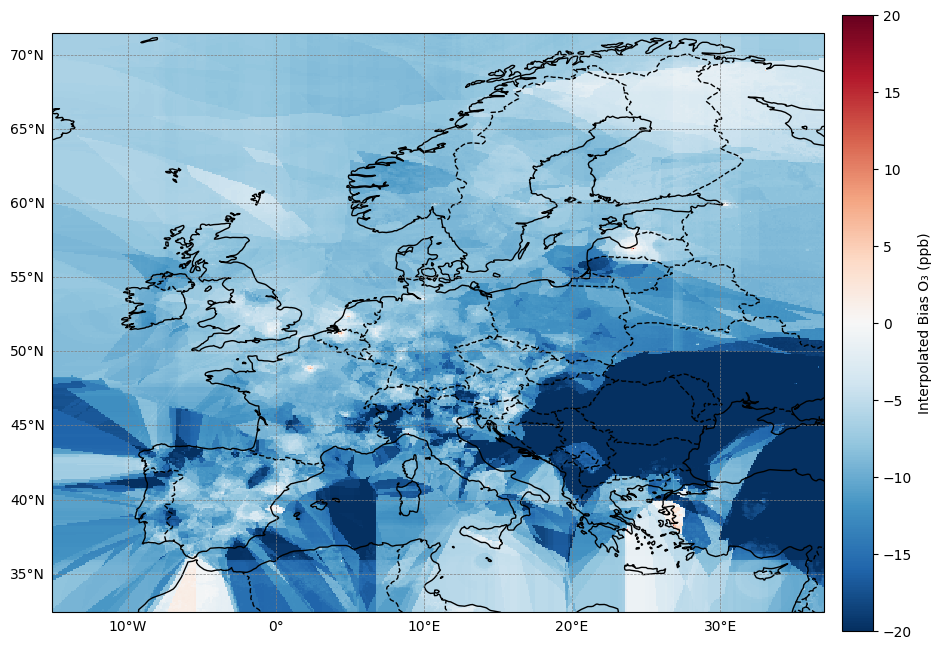

In [24]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias NetCDF File ===
bias_netcdf_path = "BaseCase_O3_Y_RF_FINAL.nc"  # Updated file name
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias (residuals)
interpolated_bias = ds_bias["Interpolated_Bias_RF"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -20  # Minimum bias value for color scale (adjust if needed)
cbar_max = 20 # Maximum bias value for color scale (adjust if needed)

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias
im = ax.pcolormesh(lon, lat, interpolated_bias, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias O₃ (ppb)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()